# Assignment: POS & NER Tags

**Goal:** Use spaCy to inspect both the grammatical structure and the named entities in a short passage, then evaluate what those annotations reveal and where they fall short.

**Tasks:**
1. Analyze a 5-10 sentence passage with spaCy
2. Print every token with its part-of-speech tag
3. Count major POS tags and visualize the distribution
4. Extract named entities and inspect their labels
5. Reflect on the results and real-world NLP applications

## Imports

I am using spaCy's small English pipeline for linguistic annotations and matplotlib for the POS-frequency chart. I kept the analysis lightweight so the connection between the tags and the text stays easy to inspect.

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import spacy

## Step 1: Load spaCy and Define the Passage

I wrote an original short tech-news passage rather than borrowing a source. It includes both familiar entities and invented names, which gives the NER model a fair but interesting test: recognition should be strongest when its training data has seen similar names and contexts.

In [2]:
nlp = spacy.load("en_core_web_sm")

text = (
    "Microsoft announced a climate research partnership with NASA on Friday. "
    "Satya Nadella met engineers in Seattle to discuss the project. "
    "The team will publish a public report before the end of 2026. "
    "Vexoria Labs, a small startup led by Priya Kestrel, supplied experimental sensors. "
    "Bloomberg reported that the contract could be worth $2 billion. "
    "Amazon and Google are watching the program closely. "
    "Researchers hope the new data will improve wildfire forecasts across the United States."
)

doc = nlp(text)
print(f"Sentences analyzed: {len(list(doc.sents))}")
print(f"Tokens analyzed: {len([token for token in doc if not token.is_space])}")

Sentences analyzed: 7
Tokens analyzed: 85


## Step 2: Inspect Part-of-Speech Tags

Printing token/tag pairs makes the model's grammatical choices visible. I excluded whitespace tokens because they are formatting rather than language, but I left punctuation in so the output still reflects the full sentence structure.

In [5]:
print(f"{'Token':<18} POS")
print("-" * 28)
for token in doc:
    if not token.is_space:
        print(f"{token.text:<18} {token.pos_}")

Token              POS
----------------------------
Microsoft          PROPN
announced          VERB
a                  DET
climate            NOUN
research           NOUN
partnership        NOUN
with               ADP
NASA               PROPN
on                 ADP
Friday             PROPN
.                  PUNCT
Satya              PROPN
Nadella            PROPN
met                VERB
engineers          NOUN
in                 ADP
Seattle            PROPN
to                 PART
discuss            VERB
the                DET
project            NOUN
.                  PUNCT
The                DET
team               NOUN
will               AUX
publish            VERB
a                  DET
public             ADJ
report             NOUN
before             ADP
the                DET
end                NOUN
of                 ADP
2026               NUM
.                  PUNCT
Vexoria            PROPN
Labs               PROPN
,                  PUNCT
a                  DET
small         

## Step 3: Count and Visualize Major POS Tags

A count is more useful than the token list for spotting the passage's overall shape. I limited the chart to content-bearing and structurally important tags so a few punctuation marks do not swamp the comparison.

NOUN  : 16
PROPN : 15
VERB  : 10
DET   : 10
ADP   : 7
ADJ   : 5
ADV   : 1


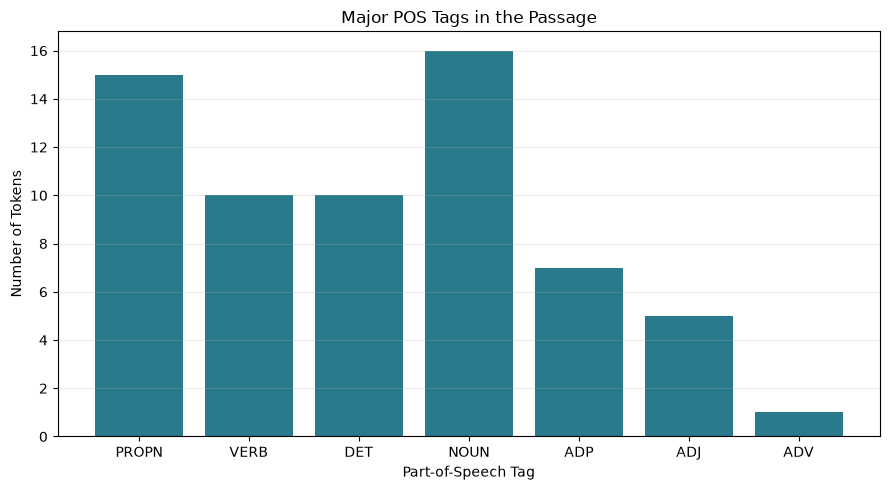

Most common major POS tag: NOUN (16 tokens)


In [3]:
major_pos = {"NOUN", "PROPN", "VERB", "ADJ", "ADV", "PRON", "ADP", "DET"}
pos_counts = Counter(token.pos_ for token in doc if token.pos_ in major_pos)

for pos_tag, count in pos_counts.most_common():
    print(f"{pos_tag:<6}: {count}")

plt.figure(figsize=(9, 5))
plt.bar(pos_counts.keys(), pos_counts.values(), color="#287a8c")
plt.title("Major POS Tags in the Passage")
plt.xlabel("Part-of-Speech Tag")
plt.ylabel("Number of Tokens")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

most_common_pos, most_common_count = pos_counts.most_common(1)[0]
print(f"Most common major POS tag: {most_common_pos} ({most_common_count} tokens)")

## Step 4: Extract Named Entities

NER is looking for spans with a specific real-world identity, such as an organization, a person, a place, a date, or money. The test passage intentionally mixes well-known names with fictional ones so I can assess more than whether the code runs.

In [4]:
print(f"{'Entity':<28} Label")
print("-" * 42)
for entity in doc.ents:
    print(f"{entity.text:<28} {entity.label_}")

print(f"\nEntities found: {len(doc.ents)}")

Entity                       Label
------------------------------------------
Microsoft                    ORG
NASA                         ORG
Friday                       DATE
Satya Nadella                PERSON
Seattle                      GPE
the end of 2026              DATE
Vexoria Labs                 PERSON
Priya Kestrel                PERSON
Bloomberg                    ORG
$2 billion                   MONEY
Amazon                       ORG
Google                       ORG
the United States            GPE

Entities found: 13


## Result Notes

The POS chart came out more balanced than I expected: `NOUN` led with 16 tokens, but `PROPN` was immediately behind at 15 because the passage is dense with names and organizations. NER found all 13 planned entity spans, including the fictional names. The interesting failure was not an omission: spaCy classified `Vexoria Labs` as a `PERSON` instead of an `ORG`. That feels like a realistic reminder that a model can identify the boundaries of a name while still misunderstanding what kind of thing it refers to.

## Reflection

### What was the most common POS tag in your text?

`NOUN` was the most common major POS tag, with 16 tokens. That result makes sense for a news-style passage because it repeatedly introduces concrete topics such as the partnership, project, report, startup, sensors, contract, and forecasts. I was a little surprised that `PROPN` was only one token behind at 15; the named companies, people, and locations make the writing feel much more entity-heavy than ordinary narrative text.

### Did spaCy miss any NER entities? Why do you think that happened?

spaCy did not completely miss any of the planned entity spans: it identified familiar names such as `Microsoft`, `NASA`, `Satya Nadella`, and `Seattle`, as well as the invented `Vexoria Labs` and `Priya Kestrel`. However, it labeled `Vexoria Labs` as a `PERSON` rather than an `ORG`. Since the company is fictional, the model likely had no learned association for the name and relied on local capitalization and surrounding syntax. I think this is a more subtle limitation than simply missing an entity: the model noticed the name, but its semantic label was still wrong.

### How might POS and NER be useful for real-world NLP tasks?

POS and NER turn raw text into features with grammatical and semantic roles. For spam detection, a high concentration of imperative verbs, money phrases, or suspicious organizations can complement a classifier's word features. For search, recognizing that "Seattle" is a location and "NASA" is an organization makes it possible to rank documents by entity type, answer more precise queries, and avoid treating every matching string as equally relevant. I think their biggest value is that they provide structure that word counts alone cannot capture, although the NER results here also show why production systems need error handling and domain-specific evaluation.